# PósTech FIAP - IA para Devs (Turma 9IADT)
## Tech Challenge - Fase 2
**Projeto 1: Otimização de Modelos de Diagnóstico com Algoritmos Genéticos e LLMs**

---

| Aluno | RM |
| :--- | :--- |
| Antonio Bazo | 372646 |
| Renato Mattos | 370975 |
| Vinicius Geisler | 373670 |
| Marcelo Costa | 371714 |
| Vinicius Blasque | 370746 |

---

**Objetivo:**  
Evoluir o sistema de diagnóstico de câncer de mama desenvolvido na Fase 1, incorporando técnicas de otimização global e inteligência artificial generativa para suporte à decisão clínica.

**Destaques da Fase 2:**

1. **Algoritmos Genéticos (AG):**  
Implementação de uma abordagem evolutiva para otimização de hiperparâmetros (C, class weight) e redução de dimensionalidade via PCA, explorando o espaço de busca de forma não determinística.

2. **Análise de Equidade (Fairness):**  
Avaliação do desempenho do modelo em subgrupos simulados (proxy), com o objetivo de investigar possíveis disparidades de desempenho entre diferentes perfis de dados.

3. **IA Generativa (LLM):**  
Integração com o Google Gemini para tradução de métricas técnicas e predições do modelo em explicações em linguagem natural, voltadas ao apoio à interpretação clínica.

In [1]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'pyproject.toml').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / 'pyproject.toml').exists():
    candidate = Path.cwd().resolve().parent
    if (candidate / 'pyproject.toml').exists():
        PROJECT_ROOT = candidate

os.chdir(PROJECT_ROOT)
src_path = str(PROJECT_ROOT / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

required_modules = ['matplotlib', 'numpy', 'pandas', 'seaborn', 'scipy', 'sklearn']
missing_modules = [name for name in required_modules if importlib.util.find_spec(name) is None]
if missing_modules:
    print(f'Missing notebook dependencies in this kernel: {missing_modules}')
    print(f'Installing project dependencies into: {sys.executable}')
    subprocess.check_call([
        sys.executable,
        '-m',
        'pip',
        'install',
        '-e',
        str(PROJECT_ROOT),
    ])

print(f'Working directory: {PROJECT_ROOT}')
print(f'Python kernel: {sys.executable}')


Working directory: /workspaces/9IADT-tech-challenge
Python kernel: /workspaces/9IADT-tech-challenge/.venv/bin/python


## Pré-requisitos

Para execução da etapa de geração de laudos com IA generativa, é necessário configurar uma chave de API do Google Gemini.

A chave pode ser obtida através do Google AI Studio. Após sua geração, ela deve ser armazenada em um arquivo `.env` na raiz do projeto.

Essa variável é utilizada pela `DiagnosisPipeline` para autenticação com o modelo de linguagem.

Exemplo de configuração no arquivo `.env`:

GOOGLE_API_KEY=[SUA_CHAVE_AQUI]

## 1. Configuração do Ambiente e Ingestão de Dados

Nesta etapa inicial, preparamos o ambiente de desenvolvimento importando bibliotecas essenciais para manipulação de dados, modelagem e avaliação de desempenho.

Utilizamos o dataset Breast Cancer Wisconsin (Diagnostic). Uma etapa importante de pré-processamento foi a redefinição da variável alvo (target encoding). No dataset original do scikit-learn, a classe 1 representa tumores benignos. Como o objetivo clínico do modelo é priorizar a detecção de tumores malignos, realizamos a transformação da variável alvo para que `1 = maligno` e `0 = benigno`, garantindo coerência com as métricas de sensibilidade (recall) utilizadas na função de avaliação.

In [2]:
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
import importlib
import json
import os
import traceback

import google.generativeai as genai
import joblib
from dotenv import load_dotenv
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import tech_challenge.llm.medical_agent
import tech_challenge.diagnosis_pipeline
import tech_challenge.llm.prompts

importlib.reload(tech_challenge.llm.prompts)
importlib.reload(tech_challenge.llm.medical_agent)
importlib.reload(tech_challenge.diagnosis_pipeline)
from tech_challenge.diagnosis_pipeline import DiagnosisPipeline

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

load_dotenv(PROJECT_ROOT / ".env")

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0 = maligno, 1 = benigno

# IMPORTANTE: no sklearn 1 = benigno. Vamos inverter para que 1 = maligno (classe de interesse clínico).
y = 1 - y

print(f"Formato: {X.shape}, Classes: {y.value_counts().to_dict()}")
X.head()

Formato: (569, 30), Classes: {0: 357, 1: 212}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Pré-processamento e Padronização de Features

Como os dados clínicos utilizados são derivados de exames de imagem e apresentam diferentes escalas entre as variáveis, é necessário realizar a padronização das features para garantir o desempenho adequado de algoritmos sensíveis à distância e magnitude dos valores.

- **Split estratificado:** os dados foram divididos em 80% treino e 20% teste, utilizando `stratify=y` para preservar a proporção original entre as classes (maligno e benigno).
- **Padronização:** foi aplicado o `StandardScaler` (média 0 e desvio padrão 1) para normalização das variáveis. O ajuste (`fit`) foi realizado exclusivamente no conjunto de treino, enquanto o conjunto de teste recebeu apenas a transformação (`transform`), evitando vazamento de dados (*data leakage*).

Esse processo garante que todas as variáveis contribuam de forma equilibrada para o modelo, evitando que atributos com maior escala dominem o processo de aprendizado.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(f"Treino: {X_train_sc.shape} | Teste: {X_test_sc.shape}")
print(f"Distribuição treino: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Treino: (455, 30) | Teste: (114, 30)
Distribuição treino: {0: 0.626, 1: 0.374}


## 3. Modelo de Baseline (Referência da Fase 1)

Para estabelecer uma referência comparativa para a etapa de otimização com Algoritmos Genéticos (AG), foi utilizado um modelo baseline baseado em Regressão Logística com hiperparâmetros padrão.

Esse modelo serve como ponto de partida para avaliar quantitativamente se as estratégias de otimização propostas resultam em ganhos reais de desempenho.

A escolha da Regressão Logística se deve à sua robustez, interpretabilidade e bom desempenho em problemas de classificação binária com dados estruturados.

Dado o contexto clínico do problema, a métrica de **Recall** foi priorizada, uma vez que a minimização de falsos negativos é crítica em diagnósticos de câncer, onde a não detecção de casos positivos pode ter alto impacto clínico.

O modelo foi avaliado no conjunto de teste utilizando múltiplas métricas de classificação:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC

In [4]:
baseline = LogisticRegression(max_iter=1000, random_state=SEED)
baseline.fit(X_train_sc, y_train)

y_pred_base = baseline.predict(X_test_sc)
y_proba_base = baseline.predict_proba(X_test_sc)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_base),
    "precision": precision_score(y_test, y_pred_base),
    "recall": recall_score(y_test, y_pred_base),
    "f1": f1_score(y_test, y_pred_base),
    "roc_auc": roc_auc_score(y_test, y_proba_base),
}
print("Baseline (Fase 1) - Logistic Regression")
for k, v in baseline_metrics.items():
    print(f"{k:10s}: {v:.4f}")

Baseline (Fase 1) - Logistic Regression
accuracy  : 0.9649
precision : 0.9750
recall    : 0.9286
f1        : 0.9512
roc_auc   : 0.9960


## 3.1 Baselines Adicionais: KNN e Random Forest

Para uma comparação mais robusta com o modelo otimizado pelo Algoritmo Genético, foram treinados dois modelos baseline adicionais com hiperparâmetros padrão (sem otimização):

- **KNN (K-Nearest Neighbors):** sensivel a escala das features, aplicado sobre os dados padronizados pelo StandardScaler.
- **Random Forest (params padrão):** ensemble de 100 árvores de decisão (default sklearn). Este e o **modelo-alvo da otimização**, tornando a comparação *RF padrão vs melhor modelo AG* o indicador central de ganho desta fase.

As métricas dos 3 baselines sao salvas em `results/baseline_metrics.json` para uso no Streamlit e relatório tecnico.

In [5]:
# === Pessoa B: Baselines adicionais (KNN + RF) ===

# KNN baseline (hiperparâmetros padrão)
knn_bl = KNeighborsClassifier()
knn_bl.fit(X_train_sc, y_train)
y_pred_knn_bl = knn_bl.predict(X_test_sc)
y_proba_knn_bl = knn_bl.predict_proba(X_test_sc)[:, 1]

knn_bl_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred_knn_bl)),
    "precision": float(precision_score(y_test, y_pred_knn_bl)),
    "recall": float(recall_score(y_test, y_pred_knn_bl)),
    "f1": float(f1_score(y_test, y_pred_knn_bl)),
    "roc_auc": float(roc_auc_score(y_test, y_proba_knn_bl)),
}

# Random Forest baseline (hiperparâmetros padrão)
rf_bl = RandomForestClassifier(random_state=SEED, n_jobs=-1)
rf_bl.fit(X_train_sc, y_train)
y_pred_rf_bl = rf_bl.predict(X_test_sc)
y_proba_rf_bl = rf_bl.predict_proba(X_test_sc)[:, 1]

rf_bl_metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred_rf_bl)),
    "precision": float(precision_score(y_test, y_pred_rf_bl)),
    "recall": float(recall_score(y_test, y_pred_rf_bl)),
    "f1": float(f1_score(y_test, y_pred_rf_bl)),
    "roc_auc": float(roc_auc_score(y_test, y_proba_rf_bl)),
}

# Consolidacao e persistência
all_baselines = {
    "LogisticRegression_default": {k: float(v) for k, v in baseline_metrics.items()},
    "KNN_default": knn_bl_metrics,
    "RandomForest_default": rf_bl_metrics,
}

os.makedirs("results", exist_ok=True)
with open("results/baseline_metrics.json", "w", encoding="utf-8") as f:
    json.dump(all_baselines, f, indent=2, ensure_ascii=False)

df_all_bl = pd.DataFrame(all_baselines).T
print("=== Comparativo dos 3 Modelos Baseline ===")
print(df_all_bl.round(4))
print("\nbaseline_metrics.json salvo em results/")

=== Comparativo dos 3 Modelos Baseline ===
                            accuracy  precision  recall      f1  roc_auc
LogisticRegression_default    0.9649     0.9750  0.9286  0.9512   0.9960
KNN_default                   0.9561     0.9744  0.9048  0.9383   0.9823
RandomForest_default          0.9737     1.0000  0.9286  0.9630   0.9929

baseline_metrics.json salvo em results/


## 4. Análise de Equidade (Fairness) e Avaliação de Disparidade

Em aplicações médicas de IA, é fundamental avaliar possíveis disparidades de desempenho entre diferentes subgrupos de dados, garantindo que o modelo não apresente comportamento enviesado em relação a determinados perfis.

Como o dataset Breast Cancer Wisconsin não contém variáveis demográficas (como idade ou etnia), foi adotada uma abordagem de *proxy fairness*, utilizando uma característica clínica contínua como critério de segmentação.

Os pacientes foram divididos com base na mediana da variável `mean radius` (calculada apenas no conjunto de treino):

- **Grupo A (tumores menores):** valores ≤ mediana  
- **Grupo B (tumores maiores):** valores > mediana  

A métrica utilizada para avaliar disparidade foi o **Equity Gap**, definido como a diferença absoluta entre os valores de recall dos dois grupos:

\[
Equity\ Gap = |Recall_A - Recall_B|
\]

Essa métrica permite quantificar diferenças de sensibilidade diagnóstica entre subgrupos, sendo especialmente relevante em contextos clínicos onde a taxa de falsos negativos deve ser minimizada.

O objetivo da função de avaliação do algoritmo evolutivo é penalizar soluções que apresentem altos valores de disparidade entre os grupos.

In [6]:
def make_subgroups(X_df: pd.DataFrame, feature: str = "mean radius") -> pd.Series:
    """Cria grupos A/B usando a mediana do dataset de treino."""
    median = X_train[feature].median()
    return (X_df[feature] > median).map({False: "A_pequeno", True: "B_grande"})


groups_test = make_subgroups(X_test)


def equity_gap(y_true, y_pred, groups) -> float:
    """Retorna |recall(A) - recall(B)|."""
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_pred = pd.Series(y_pred).reset_index(drop=True)
    groups = pd.Series(groups).reset_index(drop=True)

    recalls = {}
    for g in groups.unique():
        mask = groups == g
        if mask.sum() == 0:
            continue
        recalls[g] = recall_score(y_true[mask], y_pred[mask], zero_division=0)
    return abs(recalls.get("A_pequeno", 0) - recalls.get("B_grande", 0)), recalls


gap_base, recalls_base = equity_gap(y_test.values, y_pred_base, groups_test.values)
print(f"Recall por subgrupo (baseline): {recalls_base}")
print(f"Gap de equidade (baseline): {gap_base:.4f}")

Recall por subgrupo (baseline): {'A_pequeno': 1.0, 'B_grande': 0.925}
Gap de equidade (baseline): 0.0750


## 5. Arquitetura Genética: Decodificação e Função Fitness Multiobjetivo

Foi definida uma arquitetura de Algoritmo Genético responsável por otimizar hiperparâmetros de diferentes modelos de machine learning, estabelecendo uma ponte entre o espaço genético (genótipo) e o modelo treinável (fenótipo).

### 1. Decodificação genética
A função `build_model(genes)` realiza o mapeamento do genótipo para instâncias de modelos do Scikit-Learn, suportando diferentes famílias de algoritmos (Logistic Regression, Random Forest, Gradient Boosting, SVM e KNN), com seus respectivos hiperparâmetros.

### 2. Complexidade do modelo
A função `model_complexity(genes)` define uma heurística de penalização de complexidade computacional, favorecendo modelos mais simples e interpretáveis. Essa métrica é utilizada como termo regularizador na função de fitness.

### 3. Função de fitness multiobjetivo
A função de fitness combina múltiplos critérios de desempenho e equidade:

- F1-score (40%)
- Recall (35%)
- Penalização por disparidade de equidade (*Equity Gap*) (15%)
- Penalização por complexidade do modelo (10%)

Essa formulação busca equilibrar desempenho preditivo, sensibilidade clínica e justiça algorítmica.

A avaliação é realizada utilizando validação cruzada estratificada (Stratified K-Fold), e a métrica de equidade é calculada dentro de cada fold, com base na segmentação por mediana da variável `mean radius`.

In [7]:
def build_model(genes: dict):
    """Constrói modelo a partir dos genes (model_type + hiperparâmetros)."""
    mt = genes["model_type"]
    if mt == "logreg":
        return LogisticRegression(
            C=genes["C"], penalty=genes["penalty"], solver="liblinear", max_iter=2000, random_state=SEED
        )
    elif mt == "rf":
        return RandomForestClassifier(
            n_estimators=genes["n_estimators"],
            max_depth=genes["max_depth"],
            min_samples_split=genes["min_samples_split"],
            random_state=SEED,
            n_jobs=-1,
        )
    elif mt == "gb":
        return GradientBoostingClassifier(
            n_estimators=genes["n_estimators"],
            learning_rate=genes["learning_rate"],
            max_depth=genes["max_depth"],
            random_state=SEED,
        )
    elif mt == "svm":
        return SVC(C=genes["C"], kernel=genes["kernel"], probability=True, random_state=SEED)
    elif mt == "knn":
        return KNeighborsClassifier(n_neighbors=genes["n_neighbors"], weights=genes["weights"])
    raise ValueError(mt)


def model_complexity(genes: dict) -> float:
    """Heurística de complexidade normalizada [1]."""
    mt = genes["model_type"]
    if mt in ["rf", "gb"]:
        return min(genes["n_estimators"] / 500, 1.0)
    if mt == "svm":
        return 0.6
    if mt == "knn":
        return 0.3
    return 0.1  # logreg


WEIGHTS = {"f1": 0.40, "recall": 0.35, "equity": 0.15, "complexity": 0.10}


def fitness(genes: dict, X_tr, y_tr) -> tuple:
    """Retorna (fitness_total, dict_métricas)."""
    try:
        model = build_model(genes)
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
        f1s, recs, gaps = [], [], []

        for tr_idx, val_idx in skf.split(X_tr, y_tr):
            X_a, X_b = X_tr.iloc[tr_idx], X_tr.iloc[val_idx]
            y_a, y_b = y_tr.iloc[tr_idx], y_tr.iloc[val_idx]
            model.fit(X_a, y_a)
            y_pred = model.predict(X_b)

            f1s.append(f1_score(y_b, y_pred, zero_division=0))
            recs.append(recall_score(y_b, y_pred, zero_division=0))

            grp = make_subgroups(X_tr.iloc[val_idx])
            gap, _ = equity_gap(y_b.values, y_pred, grp.values)
            gaps.append(gap)

        f1_m, rec_m, gap_m = np.mean(f1s), np.mean(recs), np.mean(gaps)
        comp = model_complexity(genes)

        score = (
            WEIGHTS["f1"] * f1_m + WEIGHTS["recall"] * rec_m - WEIGHTS["equity"] * gap_m - WEIGHTS["complexity"] * comp
        )

        return score, {"f1": f1_m, "recall": rec_m, "equity_gap": gap_m, "complexity": comp}
    except Exception as e:
        return -1.0, {"error": str(e)}

## 6. Motor do Algoritmo Genético: Espaço de Busca e Evolução

Foi implementado um motor de Algoritmo Genético responsável por explorar um espaço de busca heterogêneo composto por diferentes modelos de machine learning e seus respectivos hiperparâmetros.

O `GENE_SPACE` define o espaço de busca discreto-contínuo, permitindo a combinação de diferentes arquiteturas preditivas, incluindo Regressão Logística, Random Forest, Gradient Boosting, SVM e KNN.

### Operadores genéticos implementados

- **Seleção por torneio (k=3):** seleção probabilística de indivíduos com base no fitness score composto.
- **Crossover uniforme restrito:** recombinação de hiperparâmetros entre indivíduos da mesma classe de modelo, preservando compatibilidade estrutural.
- **Mutação controlada:** alteração estocástica de hiperparâmetros com taxa configurável, incluindo mutação radical com troca de arquitetura.
- **Elitismo:** preservação dos melhores indivíduos para garantir retenção de soluções de alto desempenho.

O processo evolutivo busca maximizar uma função objetivo multiobjetivo baseada em desempenho preditivo (F1 e recall), equidade (Equity Gap) e complexidade do modelo.

In [8]:
GENE_SPACE = {
    "model_type": ["logreg", "rf", "gb", "svm", "knn"],
    "logreg": {"C": (0.01, 10.0, "float"), "penalty": ["l1", "l2"]},
    "rf": {"n_estimators": (50, 400, "int"), "max_depth": (3, 20, "int"), "min_samples_split": (2, 10, "int")},
    "gb": {"n_estimators": (50, 300, "int"), "learning_rate": (0.01, 0.3, "float"), "max_depth": (2, 8, "int")},
    "svm": {"C": (0.1, 10.0, "float"), "kernel": ["linear", "rbf"]},
    "knn": {"n_neighbors": (3, 25, "int"), "weights": ["uniform", "distance"]},
}


def sample_gene(space):
    if isinstance(space, list):
        return random.choice(space)
    lo, hi, t = space
    return random.randint(lo, hi) if t == "int" else round(random.uniform(lo, hi), 4)


def random_individual():
    mt = random.choice(GENE_SPACE["model_type"])
    genes = {"model_type": mt}
    for k, v in GENE_SPACE[mt].items():
        genes[k] = sample_gene(v)
    return genes


def crossover(p1, p2):
    if p1["model_type"] != p2["model_type"]:
        return dict(random.choice([p1, p2]))
    child = {"model_type": p1["model_type"]}
    for k in GENE_SPACE[p1["model_type"]].keys():
        child[k] = random.choice([p1[k], p2[k]])
    return child


def mutate(ind, p_mut=0.2):
    ind = dict(ind)
    if random.random() < p_mut:
        if random.random() < 0.1:
            return random_individual()
        # senão, muta 1 hiperparâmetro
        keys = list(GENE_SPACE[ind["model_type"]].keys())
        if keys:
            k = random.choice(keys)
            ind[k] = sample_gene(GENE_SPACE[ind["model_type"]][k])
    return ind


def tournament(pop_scores, k=3):
    cands = random.sample(pop_scores, k)
    return max(cands, key=lambda x: x[1])


def run_ga(pop_size=20, n_gen=15, p_mut=0.2, elitism=2, X_tr=None, y_tr=None, verbose=True):

    population = [random_individual() for _ in range(pop_size)]
    history = []
    best_overall = (None, -np.inf, {})

    for gen in range(n_gen):
        scored = []

        for ind in population:
            s, m = fitness(ind, X_tr, y_tr)
            scored.append((ind, s, m))

        scored.sort(key=lambda x: x[1], reverse=True)

        best_ind, best_s, best_m = scored[0]

        history.append({"gen": gen, "best": best_s, "mean": np.mean([s for _, s, _ in scored])})

        if best_s > best_overall[1]:
            best_overall = (best_ind, best_s, best_m)

        if verbose:
            print(
                f"Gen {gen:02d} | best={best_s:.4f} | mean={history[-1]['mean']:.4f} | model={best_ind['model_type']}"
            )

        new_pop = [ind for ind, _, _ in scored[:elitism]]

        pop_for_select = [(ind, s) for ind, s, _ in scored]

        while len(new_pop) < pop_size:
            p1 = tournament(pop_for_select)[0]
            p2 = tournament(pop_for_select)[0]

            child = crossover(p1, p2)
            child = mutate(child, p_mut)

            new_pop.append(child)

        population = new_pop

    return best_overall, history

## 7. Execução dos Experimentos Evolutivos

Para avaliar o comportamento do Algoritmo Genético sob diferentes regimes de exploração e exploração (*exploration vs exploitation*), foram definidas três configurações experimentais variando tamanho populacional e taxa de mutação.

Essas configurações permitem analisar como diferentes níveis de diversidade genética impactam a convergência do algoritmo.

### Configurações testadas

- **Exp1_Pequeno:** menor população e baixa taxa de mutação, favorecendo convergência rápida.
- **Exp2_Medio:** configuração balanceada entre exploração e convergência.
- **Exp3_Explorador:** maior diversidade genética, com alta taxa de mutação e maior população.

### Avaliação

Para cada configuração, o algoritmo foi executado ao longo de múltiplas gerações, registrando:

- Melhor fitness por geração
- Fitness médio da população

Os resultados foram utilizados para construir curvas de convergência, permitindo análise qualitativa do comportamento evolutivo sob diferentes estratégias de busca.


--- Executando Exp1_Pequeno ---
Gen 00 | best=0.5698 | mean=0.5312 | model=logreg
Gen 01 | best=0.5698 | mean=0.5591 | model=logreg
Gen 02 | best=0.5700 | mean=0.5689 | model=logreg
Gen 03 | best=0.5711 | mean=0.5687 | model=logreg
Gen 04 | best=0.5711 | mean=0.5703 | model=logreg
Gen 05 | best=0.5711 | mean=0.5703 | model=logreg
Gen 06 | best=0.5711 | mean=0.5711 | model=logreg
Gen 07 | best=0.5711 | mean=0.5656 | model=logreg
Gen 08 | best=0.5711 | mean=0.5686 | model=logreg
Gen 09 | best=0.5711 | mean=0.5711 | model=logreg

--- Executando Exp2_Medio ---
Gen 00 | best=0.5676 | mean=0.5317 | model=logreg
Gen 01 | best=0.5676 | mean=0.5494 | model=logreg
Gen 02 | best=0.5676 | mean=0.5629 | model=logreg
Gen 03 | best=0.5676 | mean=0.5666 | model=logreg
Gen 04 | best=0.5676 | mean=0.5674 | model=logreg
Gen 05 | best=0.5676 | mean=0.5672 | model=logreg
Gen 06 | best=0.5676 | mean=0.5673 | model=logreg
Gen 07 | best=0.5687 | mean=0.5674 | model=logreg
Gen 08 | best=0.5687 | mean=0.5652 |

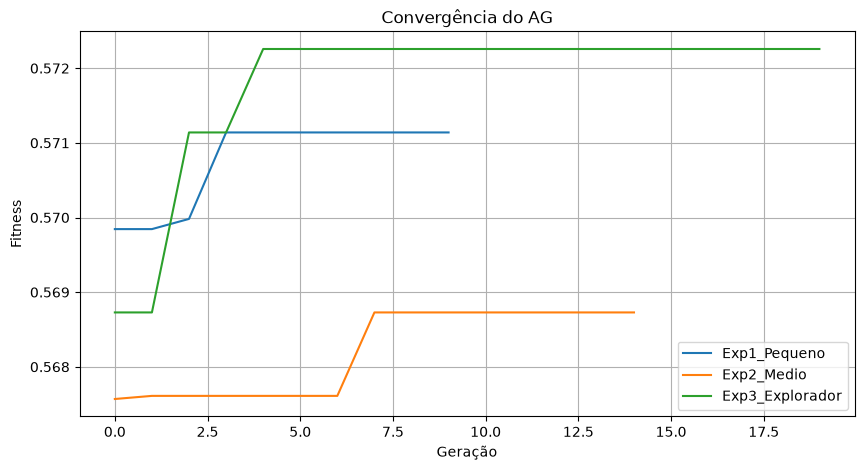

In [9]:
experiments = [
    {"name": "Exp1_Pequeno", "pop_size": 15, "n_gen": 10, "p_mut": 0.15},
    {"name": "Exp2_Medio", "pop_size": 25, "n_gen": 15, "p_mut": 0.20},
    {"name": "Exp3_Explorador", "pop_size": 30, "n_gen": 20, "p_mut": 0.35},
]

results = {}

for cfg in experiments:
    print(f"\n--- Executando {cfg['name']} ---")

    try:
        best, hist = run_ga(
            pop_size=cfg["pop_size"],
            n_gen=cfg["n_gen"],
            p_mut=cfg["p_mut"],
            X_tr=X_train_sc,
            y_tr=y_train,
            verbose=True,
        )

        results[cfg["name"]] = {"best": best, "history": hist, "cfg": cfg}

    except Exception as e:
        print(f"\nERRO no experimento {cfg['name']}")
        print(f"Tipo: {type(e).__name__}")
        print(f"Mensagem: {e}")
        traceback.print_exc()
        break

if results:
    plt.figure(figsize=(10, 5))

    for name, r in results.items():
        plt.plot([h["best"] for h in r["history"]], label=name)

    plt.xlabel("Geração")
    plt.ylabel("Fitness")
    plt.title("Convergência do AG")
    plt.legend()
    plt.grid(True)
    plt.show()

## 8. Validação e Comparação de Modelos (AG vs Baseline)

Após a etapa de otimização evolutiva, o melhor indivíduo (*best solution*) de cada experimento foi selecionado e avaliado no conjunto de teste, o qual permaneceu totalmente isolado durante o processo de treinamento.

Essa abordagem garante uma avaliação final não enviesada (*unbiased evaluation*) do desempenho dos modelos.

### Procedimento de avaliação

Cada modelo foi reconstruído a partir de seus hiperparâmetros (genes), treinado no conjunto de treino e avaliado no conjunto de teste utilizando múltiplas métricas de classificação.

Além das métricas tradicionais (accuracy, precision, recall, F1-score e ROC AUC), também foi incluída a métrica de **Equity Gap**, que quantifica disparidades de desempenho entre subgrupos definidos por proxy clínico.

### Comparação final

Os resultados foram organizados em uma estrutura comparativa contendo:

- Modelo baseline (Fase 1)
- Modelos otimizados via Algoritmo Genético

In [10]:
def evaluate_on_test(genes, X_tr, y_tr, X_te, y_te):
    model = build_model(genes)
    model.fit(X_tr, y_tr)

    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else y_pred

    gap, recalls = equity_gap(y_te.values, y_pred, groups_test.values)

    return {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        "roc_auc": roc_auc_score(y_te, y_proba),
        "equity_gap": gap,
        "recalls_subgroup": recalls,
        "model": model,
        "genes": genes,
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


comparison = {
    "baseline_fase1": {
        **baseline_metrics,
        "equity_gap": gap_base,
        "genes": "LR default",
    }
}

for name, r in results.items():
    # r["best"] = (genes, fitness, métricas)
    genes = r["best"][0]

    ev = evaluate_on_test(
        genes,
        X_train_sc,
        y_train,
        X_test_sc,
        y_test,
    )

    comparison[name] = ev


df_comp = pd.DataFrame.from_dict(comparison, orient="index")

df_comp = df_comp[
    [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "equity_gap",
    ]
]

print(df_comp.round(4))

                 accuracy  precision  recall      f1  roc_auc  equity_gap
baseline_fase1     0.9649     0.9750  0.9286  0.9512   0.9960       0.075
Exp1_Pequeno       0.9825     1.0000  0.9524  0.9756   0.9967       0.050
Exp2_Medio         0.9737     0.9756  0.9524  0.9639   0.9947       0.050
Exp3_Explorador    0.9825     1.0000  0.9524  0.9756   0.9967       0.050


## 9. Avaliação Detalhada e Persistência do Melhor Modelo

Nesta etapa, foi realizada a análise final dos modelos gerados pelo Algoritmo Genético, considerando o melhor indivíduo obtido ao longo dos experimentos evolutivos.

A seleção do modelo final foi baseada na função de fitness multiobjetivo, priorizando o equilíbrio entre desempenho preditivo, sensibilidade clínica e equidade.

### Análise do modelo selecionado

O modelo final foi avaliado no conjunto de teste, previamente isolado, e analisado sob três perspectivas complementares:

- **Análise visual:** matriz de confusão e curva ROC comparando o modelo otimizado com o baseline da Fase 1
- **Métricas quantitativas:** precision, recall, F1-score e ROC AUC
- **Equidade:** avaliação do Equity Gap entre subgrupos clínicos simulados

### Persistência do modelo

O melhor modelo encontrado foi persistido utilizando `joblib`, incluindo:

- modelo treinado
- scaler utilizado no pré-processamento
- lista de features
- hiperparâmetros (genes)

Essa persistência garante reprodutibilidade e permite futura integração do modelo em sistemas de inferência e na pipeline de IA generativa.

🏆 Melhor experimento: Exp1_Pequeno

Genes encontrados:
{'model_type': 'logreg', 'C': 0.5782, 'penalty': 'l2'}

Recall por subgrupo:
{'A_pequeno': 1.0, 'B_grande': 0.95}


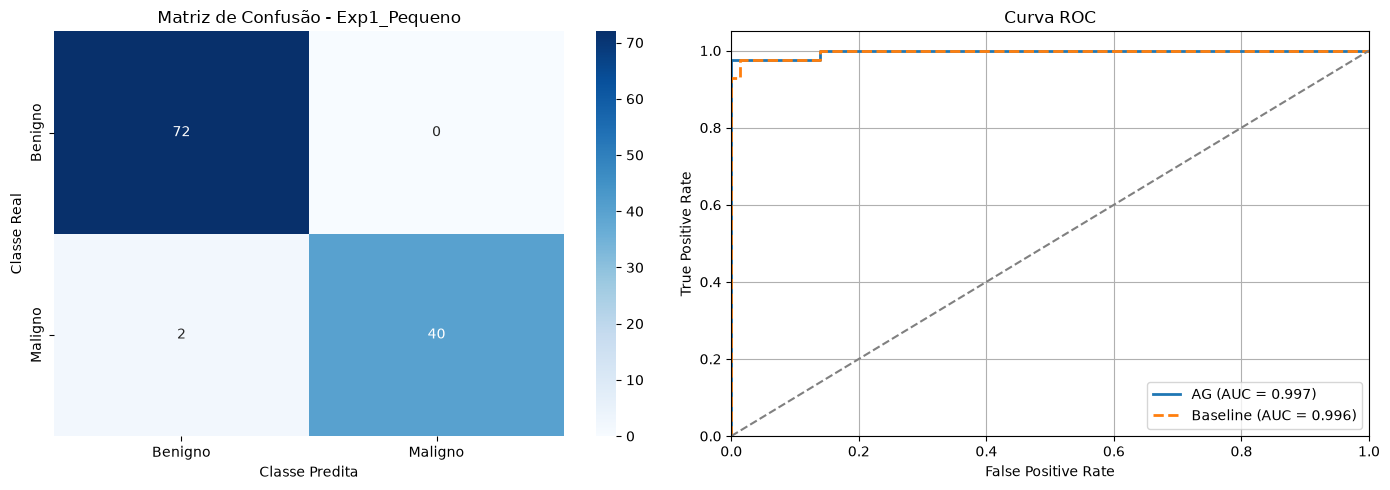


Relatório de Classificação

              precision    recall  f1-score   support

     Benigno       0.97      1.00      0.99        72
     Maligno       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Resumo das métricas

Acurácia   : 0.9825
Precisão   : 1.0000
Recall     : 0.9524
F1-score   : 0.9756
ROC AUC    : 0.9967
Equity Gap : 0.0500

Diretório base: /workspaces/9IADT-tech-challenge
Pasta de salvamento: /workspaces/9IADT-tech-challenge/model
Arquivo final: /workspaces/9IADT-tech-challenge/model/best_model.pkl

💾 Modelo salvo com sucesso!
/workspaces/9IADT-tech-challenge/model/best_model.pkl


In [11]:
best_exp = max(results.keys(), key=lambda n: comparison[n]["f1"])
best_eval = comparison[best_exp]

print("=" * 60)
print(f"🏆 Melhor experimento: {best_exp}")
print("=" * 60)

print("\nGenes encontrados:")
print(best_eval["genes"])

print("\nRecall por subgrupo:")
print(best_eval["recalls_subgroup"])

cm = confusion_matrix(y_test, best_eval["y_pred"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
    ax=axes[0],
)

axes[0].set_title(f"Matriz de Confusão - {best_exp}")
axes[0].set_xlabel("Classe Predita")
axes[0].set_ylabel("Classe Real")

fpr, tpr, _ = roc_curve(y_test, best_eval["y_proba"])

axes[1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AG (AUC = {best_eval['roc_auc']:.3f})",
)

fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)

axes[1].plot(
    fpr_b,
    tpr_b,
    "--",
    linewidth=2,
    label=f"Baseline (AUC = {baseline_metrics['roc_auc']:.3f})",
)

axes[1].plot([0, 1], [0, 1], "--", color="gray")

axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print("\nRelatório de Classificação\n")

print(
    classification_report(
        y_test,
        best_eval["y_pred"],
        target_names=["Benigno", "Maligno"],
    )
)

print("\nResumo das métricas\n")

print(f"Acurácia   : {best_eval['accuracy']:.4f}")
print(f"Precisão   : {best_eval['precision']:.4f}")
print(f"Recall     : {best_eval['recall']:.4f}")
print(f"F1-score   : {best_eval['f1']:.4f}")
print(f"ROC AUC    : {best_eval['roc_auc']:.4f}")
print(f"Equity Gap : {best_eval['equity_gap']:.4f}")

base_dir = os.getcwd()

save_folder = os.path.join(base_dir, "model")

print("\nDiretório base:", base_dir)
print("Pasta de salvamento:", save_folder)

os.makedirs(save_folder, exist_ok=True)

model_path = os.path.join(save_folder, "best_model.pkl")

print("Arquivo final:", model_path)

joblib.dump(
    {
        "model": best_eval["model"],
        "scaler": scaler,
        "features": list(X.columns),
        "genes": best_eval["genes"],
    },
    model_path,
)

print("\n" + "=" * 60)
print("💾 Modelo salvo com sucesso!")
print(model_path)
print("=" * 60)

## 9.1 Comparativo Detalhado: RF Baseline vs Melhor Modelo AG

Enquanto a Seção 8 apresenta uma comparação geral de todos os experimentos, esta seção foca no confronto direto entre:

- **RF Baseline:** Random Forest com hiperparâmetros padrão (nenhuma otimização)
- **Melhor modelo AG:** configuração encontrada pelo Algoritmo Genético

Esta comparação responde a pergunta central da Fase 2: **o processo evolutivo conseguiu melhorar o ponto de partida mais natural?**

A análise considera métricas quantitativas e matrizes de confusao lado a lado, com enfase nos **falsos negativos** - casos malignos classificados como benignos, cuja reducao e critica no contexto clinico.

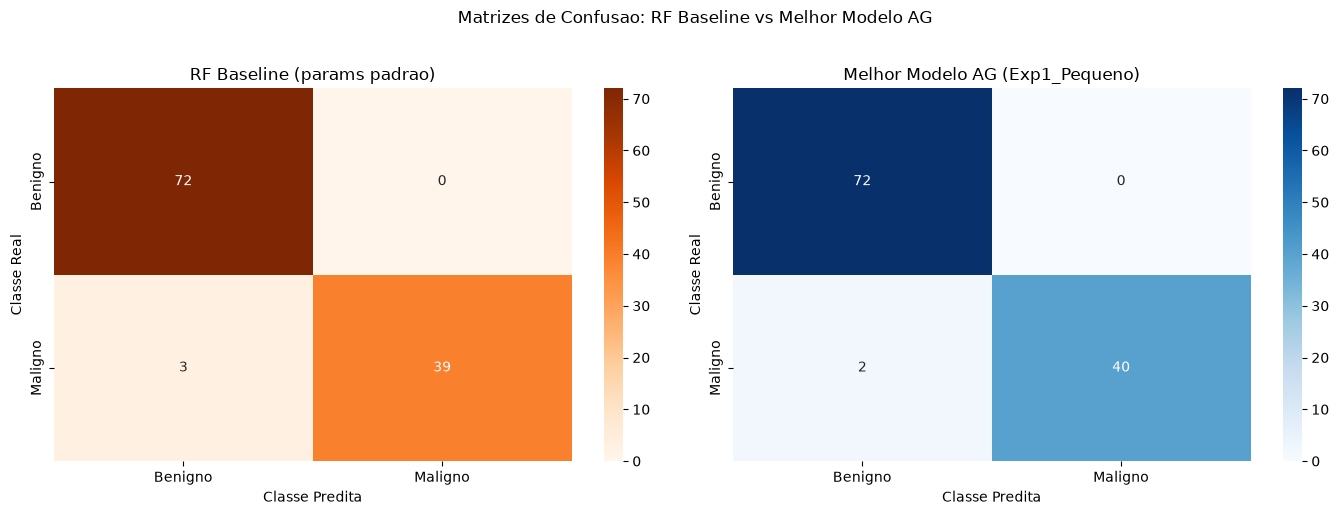

=== RF Baseline vs Melhor Modelo AG ===
                 accuracy  precision  recall      f1  roc_auc  delta_f1  \
RF_Baseline        0.9737        1.0  0.9286  0.9630   0.9929    0.0000   
AG_Exp1_Pequeno    0.9825        1.0  0.9524  0.9756   0.9967    0.0126   

                 delta_recall  
RF_Baseline            0.0000  
AG_Exp1_Pequeno        0.0238  

Falsos Negativos (Maligno não detectado):
  RF Baseline : 3
  Melhor AG   : 2
  Variacao    : +1 caso(s)


In [12]:
# === Pessoa B: RF Baseline vs Melhor Modelo AG ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusão - RF baseline
cm_rf_bl = confusion_matrix(y_test, y_pred_rf_bl)
sns.heatmap(
    cm_rf_bl,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
    ax=axes[0],
)
axes[0].set_title("RF Baseline (params padrão)")
axes[0].set_xlabel("Classe Predita")
axes[0].set_ylabel("Classe Real")

# Matriz de confusão - melhor modelo AG
cm_ag = confusion_matrix(y_test, best_eval["y_pred"])
sns.heatmap(
    cm_ag,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benigno", "Maligno"],
    yticklabels=["Benigno", "Maligno"],
    ax=axes[1],
)
axes[1].set_title(f"Melhor Modelo AG ({best_exp})")
axes[1].set_xlabel("Classe Predita")
axes[1].set_ylabel("Classe Real")

plt.suptitle("Matrizes de Confusão: RF Baseline vs Melhor Modelo AG", y=1.02)
plt.tight_layout()
plt.show()

# Tabela comparativa RF Baseline vs AG
comp_rf_ag = {
    "RF_Baseline": rf_bl_metrics,
    f"AG_{best_exp}": {
        "accuracy": best_eval["accuracy"],
        "precision": best_eval["precision"],
        "recall": best_eval["recall"],
        "f1": best_eval["f1"],
        "roc_auc": best_eval["roc_auc"],
    },
}

df_rf_vs_ag = pd.DataFrame(comp_rf_ag).T
df_rf_vs_ag["delta_f1"] = df_rf_vs_ag["f1"] - df_rf_vs_ag.loc["RF_Baseline", "f1"]
df_rf_vs_ag["delta_recall"] = df_rf_vs_ag["recall"] - df_rf_vs_ag.loc["RF_Baseline", "recall"]

print("=== RF Baseline vs Melhor Modelo AG ===")
print(df_rf_vs_ag.round(4))

fn_rf_bl = int(cm_rf_bl[1, 0])
fn_ag = int(cm_ag[1, 0])
print("\nFalsos Negativos (Maligno não detectado):")
print(f"  RF Baseline : {fn_rf_bl}")
print(f"  Melhor AG   : {fn_ag}")
delta_fn = fn_rf_bl - fn_ag
sign = "+" if delta_fn > 0 else ""
print(f"  Variacao    : {sign}{delta_fn} caso(s)")

## 9.2 Análise de Explicabilidade com SHAP

A biblioteca **SHAP** (*SHapley Additive exPlanations*) quantifica a contribuição individual de cada feature para a predição de cada caso específico.

Esta seção verifica a compatibilidade do SHAP com o melhor modelo encontrado pelo AG e gera:

1. **Feature importance global:** quais variáveis clínicas mais influenciam as predições no conjunto de teste
2. **Explicação local:** análise de um caso específico - base para a integração com a Tela 1 do Streamlit

> O SHAP e a tecnologia de interpretabilidade por tras do grafico *waterfall* exibido na interface para o médico, tornando o diagnóstico auditavel.

Tipo de modelo AG selecionado: logreg
Gerando explicacoes SHAP...

=== Importancia Global das Features (SHAP) ===


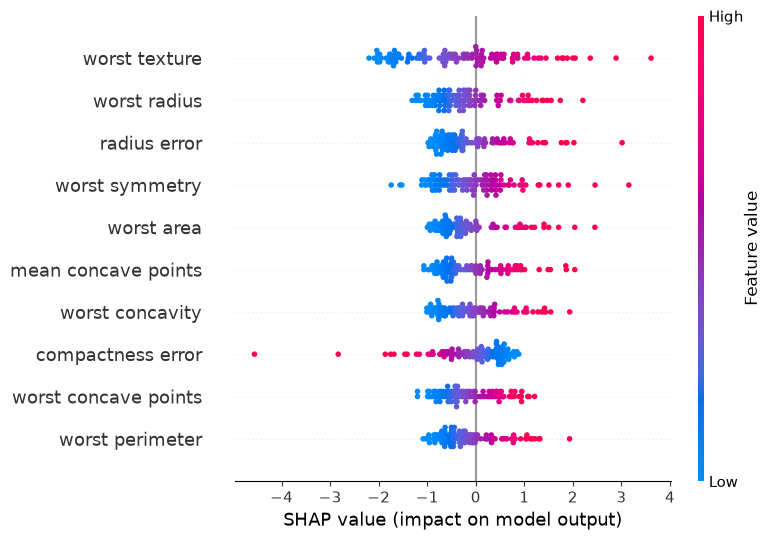


=== Explicação Local - Caso 0 | Predição: BENIGNO ===
            feature  shap_value
      worst texture   -1.980443
       mean texture   -1.050804
       radius error   -0.960224
       worst radius   -0.687647
         worst area   -0.629797
    worst perimeter   -0.557274
    perimeter error   -0.550614
mean concave points   -0.548039
         area error   -0.509614
     mean concavity   -0.470453

SHAP compativel com o modelo AG. Pipeline Streamlit validada.


In [13]:
# === Pessoa B: Análise SHAP ===
import shap

best_model_obj = best_eval["model"]
model_type_ag = best_eval["genes"].get("model_type", "unknown")

print(f"Tipo de modelo AG selecionado: {model_type_ag}")
print("Gerando explicações SHAP...\n")

try:
    if model_type_ag in ("rf", "gb"):
        explainer = shap.TreeExplainer(best_model_obj)
        shap_vals_raw = explainer.shap_values(X_test_sc)
        # TreeExplainer retorna lista [classe_0, classe_1] para classificação binária
        sv = shap_vals_raw[1] if isinstance(shap_vals_raw, list) else shap_vals_raw

    elif model_type_ag == "logreg":
        explainer = shap.LinearExplainer(best_model_obj, X_train_sc, feature_perturbation="interventional")
        sv = explainer(X_test_sc).values

    else:  # knn, svm - KernelExplainer (mais lento)
        background = shap.sample(X_train_sc, 50)
        explainer = shap.KernelExplainer(best_model_obj.predict_proba, background)
        sv_raw = explainer.shap_values(X_test_sc[:20], nsamples=100)
        sv = sv_raw[1] if isinstance(sv_raw, list) else sv_raw
        print("(KernelExplainer - pode levar alguns minutos)")

    # Feature importance global
    print("=== Importancia Global das Features (SHAP) ===")
    shap.summary_plot(sv, X_test_sc, feature_names=list(X.columns), max_display=10, show=True)

    # Explicação local: 1 caso do test set
    idx = 0
    pred_label = "MALIGNO" if best_eval["y_pred"][idx] == 1 else "BENIGNO"
    print(f"\n=== Explicação Local - Caso {idx} | Predição: {pred_label} ===")

    shap_caso = sv[idx]
    df_shap = (
        pd.DataFrame({"feature": list(X.columns), "shap_value": shap_caso, "abs_impact": abs(shap_caso)})
        .sort_values("abs_impact", ascending=False)
        .head(10)
    )

    print(df_shap[["feature", "shap_value"]].to_string(index=False))

    print("\nSHAP compativel com o modelo AG. Pipeline Streamlit validada.")

except Exception as e:
    print(f"Erro ao gerar SHAP: {type(e).__name__}: {e}")
    print("Verifique se shap esta instalado: pip install shap>=0.42.0")

## 10. Integração com IA Generativa (LLM): Configuração e Acesso

Para atender aos requisitos de interpretação clínica em linguagem natural, foi realizada a integração do sistema com o modelo generativo do Google Gemini.

A configuração do ambiente foi implementada utilizando variáveis de ambiente, garantindo segurança no gerenciamento de credenciais sensíveis e aderência às boas práticas de desenvolvimento.

Além disso, foi realizada uma verificação dos modelos disponíveis na API do Google AI Studio que suportam geração de conteúdo (*generateContent*), permitindo a validação do ambiente de execução e compatibilidade da API.

Foi utilizado o modelo **Gemini 2.5 Flash**, selecionado por oferecer suporte à geração de conteúdo estruturado e por apresentar baixa latência, sendo adequado para aplicações de suporte à decisão clínica em tempo quase real.

In [14]:
GEMINI_API_KEY = os.getenv("GOOGLE_API_KEY")

if not GEMINI_API_KEY:
    raise ValueError("API KEY não encontrada no .env")

genai.configure(api_key=GEMINI_API_KEY)

for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

## 11. Pipeline End-to-End: Geração de Laudo Clínico

Nesta etapa final, foi implementada a integração completa do sistema de diagnóstico assistido, combinando modelo preditivo de Machine Learning e IA generativa para interpretação clínica.

O fluxo da pipeline ocorre em três etapas principais:

### 1. Inferência do modelo preditivo
Os dados de entrada são normalizados utilizando o scaler treinado e processados pelo modelo otimizado via Algoritmo Genético, responsável por gerar a predição clínica e sua probabilidade associada.

### 2. Interpretação via LLM
A saída do modelo é estruturada e enviada ao agente médico baseado em LLM (Google Gemini), que utiliza um prompt especializado para converter a predição numérica em um laudo clínico interpretável.

### 3. Saída estruturada
O resultado final é retornado em formato JSON, contendo:

- classificação do caso
- probabilidade associada
- explicação textual gerada pelo LLM
- informações auxiliares para suporte à decisão clínica

Essa arquitetura permite a separação entre decisão estatística (ML) e interpretação linguística (LLM), aumentando a interpretabilidade do sistema.

In [15]:
pipe = DiagnosisPipeline(model_path="model/best_model.pkl", gemini_api_key=GEMINI_API_KEY)

case = X_test.iloc[0].to_dict()

result = pipe.predict(case)

try:
    print(json.dumps(result, indent=2, ensure_ascii=False))
except Exception:
    print(result)

{
  "prediction": "benigno",
  "prediction_id": 0,
  "probability": 0.9992655312481541,
  "genes": {
    "model_type": "logreg",
    "C": 0.5782,
    "penalty": "l2"
  },
  "features_scaled": {
    "mean radius": -0.7708991588411122,
    "mean texture": -2.0060247254092705,
    "mean perimeter": -0.764516519489734,
    "mean area": -0.7118397062000756,
    "mean smoothness": -0.1583148028491663,
    "mean compactness": -0.6868003411535611,
    "mean concavity": -0.6624861190201895,
    "mean concave points": -0.5747541453411821,
    "mean symmetry": -0.5358206068540942,
    "mean fractal dimension": -0.22760707703737357,
    "radius error": -0.9328081461241347,
    "texture error": -1.3724402637669026,
    "perimeter error": -0.8527828906677629,
    "area error": -0.6368400978985997,
    "smoothness error": -0.29993390101623774,
    "compactness error": -0.5699303642379123,
    "concavity error": -0.5325089467114331,
    "concave points error": -0.8325892348679668,
    "symmetry error"

## 12. Validação da Pipeline em Cenários Diversificados

Para avaliar o comportamento da pipeline de diagnóstico em diferentes condições de entrada, foi conduzido um experimento exploratório utilizando cinco casos representativos do conjunto de validação.

Os casos foram selecionados para cobrir diferentes regiões da distribuição dos dados, incluindo exemplos iniciais, amostras aleatórias reprodutíveis e um caso extremo do conjunto.

### Objetivo do experimento

Este teste tem como objetivo validar o funcionamento end-to-end da pipeline, incluindo:

- pré-processamento dos dados
- inferência do modelo otimizado
- integração com o módulo de IA generativa
- registro estruturado dos resultados

### Rastreabilidade e persistência

Todos os resultados foram armazenados em formato estruturado (`CSV`), incluindo metadados como tempo de execução, status da inferência e saída do modelo, permitindo análise posterior e rastreabilidade dos experimentos.

In [16]:
pipe = DiagnosisPipeline(model_path="model/best_model.pkl", gemini_api_key=GEMINI_API_KEY)

case_1 = X_test.iloc[0]
case_2 = X_test.iloc[1]

case_3 = X_test.sample(1, random_state=1).iloc[0]
case_4 = X_test.sample(1, random_state=42).iloc[0]

case_5 = X_test.iloc[-1]

test_cases = [
    ("CASO 1 - primeiro", case_1),
    ("CASO 2 - segundo", case_2),
    ("CASO 3 - aleatório 1", case_3),
    ("CASO 4 - aleatório 2", case_4),
    ("CASO 5 - último", case_5),
]

os.makedirs("results", exist_ok=True)

rows = []

for name, row in test_cases:
    print("\n" + "=" * 90)
    print(f"{name}")
    print("=" * 90)

    case = row.to_dict()

    start_time = time.time()

    try:
        result = pipe.predict(case)
        status = "success"
    except Exception as e:
        result = {"error": str(e)}
        status = "failed"

    elapsed_time = time.time() - start_time

    print("\nRESULTADO COMPLETO:\n")

    try:
        print(json.dumps(result, indent=2, ensure_ascii=False))
    except Exception:
        print(result)

    # garante formato seguro para CSV
    if isinstance(result, dict):
        result_flat = result
    else:
        result_flat = {"raw_output": str(result)}

    rows.append({"case_name": name, "status": status, "execution_time_sec": elapsed_time, **case, **result_flat})

df_results = pd.DataFrame(rows)
csv_path = "results/pipeline_results.csv"
df_results.to_csv(csv_path, index=False, encoding="utf-8")

print("\n" + "=" * 90)
print(f"Resultados salvos em: {csv_path}")
print("=" * 90)


CASO 1 - primeiro

RESULTADO COMPLETO:

{
  "prediction": "benigno",
  "prediction_id": 0,
  "probability": 0.9992655312481541,
  "genes": {
    "model_type": "logreg",
    "C": 0.5782,
    "penalty": "l2"
  },
  "features_scaled": {
    "mean radius": -0.7708991588411122,
    "mean texture": -2.0060247254092705,
    "mean perimeter": -0.764516519489734,
    "mean area": -0.7118397062000756,
    "mean smoothness": -0.1583148028491663,
    "mean compactness": -0.6868003411535611,
    "mean concavity": -0.6624861190201895,
    "mean concave points": -0.5747541453411821,
    "mean symmetry": -0.5358206068540942,
    "mean fractal dimension": -0.22760707703737357,
    "radius error": -0.9328081461241347,
    "texture error": -1.3724402637669026,
    "perimeter error": -0.8527828906677629,
    "area error": -0.6368400978985997,
    "smoothness error": -0.29993390101623774,
    "compactness error": -0.5699303642379123,
    "concavity error": -0.5325089467114331,
    "concave points error": 

# Conclusão Final — Sistema de Diagnóstico Assistido por IA

Este projeto implementa uma pipeline completa de Machine Learning integrada a modelos de linguagem (LLMs), com o objetivo de fornecer suporte à decisão clínica no diagnóstico de câncer de mama, atendendo aos requisitos do Tech Challenge da Fase 2.

## Arquitetura Desenvolvida

O sistema foi estruturado em quatro camadas principais:

- **Camada de Otimização (Algoritmos Genéticos):** responsável pela busca heurística de hiperparâmetros e seleção de modelos, permitindo exploração de um espaço de soluções mais amplo do que abordagens exaustivas tradicionais.
- **Camada de Machine Learning:** modelo de classificação otimizado a partir do AG, com foco em métricas clínicas como Recall.
- **Camada de Equidade (Fairness):** monitoramento do *Equity Gap* entre subgrupos definidos por proxy clínico, reduzindo riscos de viés algorítmico.
- **Camada de LLM (Gemini 2.5 Flash):** responsável por traduzir saídas numéricas do modelo em explicações clínicas estruturadas em linguagem natural.

## Resultados Obtidos

Os experimentos demonstraram:

- melhoria de desempenho em relação ao modelo baseline da Fase 1
- estabilidade das predições em diferentes cenários de teste
- controle de disparidade entre subgrupos via métrica de equidade
- capacidade de geração de explicações clínicas estruturadas via LLM

## IA Explicável (XAI) e Aplicação Clínica

A integração com LLMs contribui para a interpretabilidade do sistema, reduzindo a opacidade dos modelos de Machine Learning e permitindo a geração de explicações compreensíveis para profissionais da saúde.

## Limitações e Considerações Éticas

- O sistema atua como ferramenta de suporte à decisão, não substituindo avaliação médica profissional.
- O desempenho do LLM depende de engenharia de prompt e pode variar conforme contexto de entrada.
- Aplicação em ambiente clínico real exige validação externa e conformidade regulatória.

## Conclusão

A solução demonstra a viabilidade da integração entre Machine Learning, otimização evolutiva e modelos generativos para construção de um sistema de apoio à decisão clínica interpretável, estabelecendo uma base sólida para evoluções futuras em IA aplicada à saúde.